# Import Libraries

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from IPython.display import Audio, display

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchaudio
import torch.optim as optim 
import torchaudio.functional as F
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

from glob import glob
import random
from tqdm import tqdm
import soundfile as sf

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import os
import sys
import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.callbacks.early_stopping import EarlyStopping

from sklearn.metrics import f1_score , accuracy_score, classification_report, confusion_matrix
import math

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("github_access")

!rm -rf /kaggle/working/dl-genai-project-26-t1

!git clone https://{secret_value_0}@github.com/Aryanch9797/dl-genai-project-26-t1.git

repo_path = "/kaggle/working/dl-genai-project-26-t1"
if repo_path not in sys.path:
    sys.path.append(repo_path)

from src.Trainers.custom_trainer import training_model
from src.models.AST import AST_model
from src.inference.inference import prediction
from src.models.scratch_CNN import CNN_mashup_model
from src.models.Resnet_50 import ResNet50_GenreClassifier

device: cuda
Cloning into 'dl-genai-project-26-t1'...
remote: Enumerating objects: 382, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 382 (delta 10), reused 8 (delta 5), pack-reused 361 (from 1)
Receiving objects: 100% (382/382), 64.46 MiB | 23.31 MiB/s, done.
Resolving deltas: 100% (216/216), done.


2026-02-28 07:03:26.751473: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772262206.929707      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772262206.978689      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772262207.402186      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772262207.402226      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772262207.402229      25 computation_placer.cc:177] computation placer alr

# Data Loader

In [2]:
test_csv = pd.read_csv("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv" , index_col='id')
sample_submission = pd.read_csv("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv" , index_col='id' )
path = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/"

In [3]:
label_to_genre = {
    0: "blues", 1: "classical", 2: "country", 3: "disco", 4: "hiphop",
    5: "jazz", 6: "metal", 7: "pop", 8: "reggae", 9: "rock"
}

# CNN

In [4]:
CNN_model = CNN_mashup_model(7,3,16000,0.2,32)


In [5]:
CNN_model.to(device)
CNN_model.load_state_dict(torch.load("/kaggle/input/models/aryanchauhan97971234/scratch_cnn_3_4_v3/pytorch/7_3_22050_0.2_32/1/Scratch_CNN.pth"))

<All keys matched successfully>

In [6]:
from src.dataset.test_dataset import test_mashed_dataset
from src.dataset.train_val_dataset import MelSpectrogramDataset

test_data = test_mashed_dataset(path, test_csv, 16000, 10.24)
# batch_size 1 for test data so all audio chunk can be processed together
test_loader = DataLoader(test_data , batch_size=1, shuffle=False, num_workers=4,pin_memory=True)

In [7]:
# preds = prediction(CNN_model, test_loader, device)
# sample_submission['genre'] = [label_to_genre[i] for i in preds]
# sample_submission.to_csv("submission.csv")
# sns.countplot(sample_submission['genre'])
# plt.show()

# ResNet50

In [8]:
ResNet_model = ResNet50_GenreClassifier()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 227MB/s]


In [9]:
ResNet_model.to(device)
ResNet_model.load_state_dict(torch.load("/kaggle/input/models/aryanchauhan97971234/resnet-50/pytorch/0.3_dropout/2/ResNet.pth"))

<All keys matched successfully>

In [10]:
# preds = prediction(ResNet_model, test_loader, device)
# sample_submission['genre'] = [label_to_genre[i] for i in preds]
# sample_submission.to_csv("submission.csv")
# sns.countplot(sample_submission['genre'])
# plt.show()

# AST (Audio Spectrogram Transformer)

In [11]:
ast_model = AST_model(lr=1e-5)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
from src.dataset.test_dataset_for_AST import test_mashed_dataset
from src.dataset.train_val_dataset_for_AST import MelSpectrogramDataset

test_data_for_AST = test_mashed_dataset(path, test_csv, 16000, 10.24)
# batch_size 1 for test data so all audio chunk can be processed together
test_loader_for_AST = DataLoader(test_data_for_AST , batch_size=1, shuffle=False, num_workers=4,pin_memory=True)

In [13]:
ast_model.to(device)
ast_model.load_state_dict(torch.load("/kaggle/input/models/aryanchauhan97971234/ast_stretch/pytorch/full_tuned_ast/1/AST.pth"))

<All keys matched successfully>

In [14]:
# preds = prediction(ast_model, test_loader_for_AST, device)
# sample_submission['genre'] = [label_to_genre[i] for i in preds]
# sample_submission.to_csv("submission.csv")
# sns.countplot(sample_submission['genre'])
# plt.show()

Starting Ensemble on cuda...


3020it [07:27,  6.75it/s]


Ensemble complete. Saved to 'submission.csv'


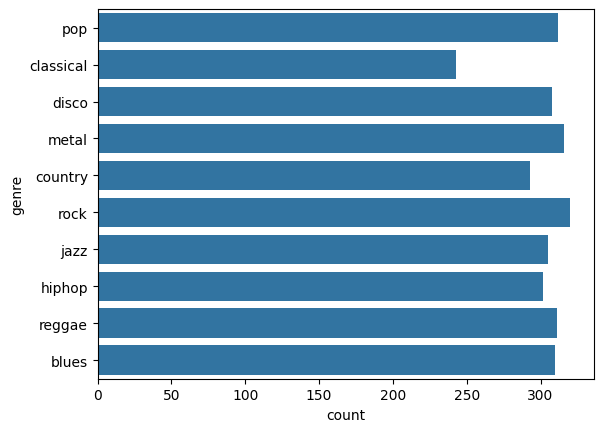

In [15]:
from src.inference.ensemble_inference import ensemble_and_submit
# Run the ensemble

df_submission = ensemble_and_submit(
    models = [CNN_model, ResNet_model],
    loader=test_loader,
    label_map=label_to_genre,
    device=device,
    AST_model=ast_model,
    AST_loader = test_loader_for_AST
 )

sns.countplot(df_submission['genre'])
plt.show()